In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

**1. Зниження розмірності і візуалізація даних**

In [6]:
from sklearn.decomposition    import PCA
from sklearn.manifold         import TSNE

import plotly.express as px

In [7]:
df = pd.read_csv("Admission_Predict.csv")
df = df.fillna(df.mean())
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [8]:
df = df.drop(columns=['Serial No.'])
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [9]:
df.rename(columns={'Serial No.':'Srno','GRE Score':'GRE','TOEFL Score':'TOEFL',
                   'University Rating':'UnivRating','Chance of Admit ':'Chance'},inplace=True)
df.head()

,GRE,TOEFL,UnivRating,SOP,LOR,CGPA,Research,Chance
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [10]:
def class_chance(row):
    if row['Chance'] > 0.7 :
        return 1
    else :
        return 0

In [11]:
df['Admit'] = df.apply(class_chance,axis=1)
df.head()

,GRE,TOEFL,UnivRating,SOP,LOR,CGPA,Research,Chance,Admit
0,337,118,4,4.5,4.5,9.65,1,0.92,1
1,324,107,4,4.0,4.5,8.87,1,0.76,1
2,316,104,3,3.0,3.5,8.00,1,0.72,1
3,322,110,3,3.5,2.5,8.67,1,0.80,1
4,314,103,2,2.0,3.0,8.21,0,0.65,0


In [12]:
features = ['GRE', 'TOEFL', 'UnivRating', 'SOP', 'CGPA', 'Research']

In [18]:
y = df['Admit']

In [19]:
X = df[features]
pca = PCA(n_components=2).fit(X)

X_pca = pca.transform(X)
X_tsne = TSNE(n_components=2).fit_transform(X)

Text(0.5, 1.0, 'TSNE')

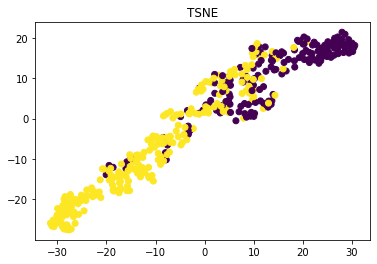

In [20]:
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y)
plt.title('TSNE')

Text(0.5, 1.0, 'PCA')

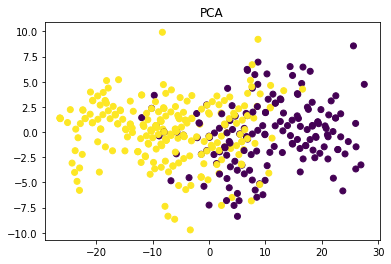

In [21]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.title('PCA')

**2. Кластерний аналіз**

1) За допомогою алгоритму k-means зробити квантування зображення з глибиною 64, 32, 16, 8 рівнів

In [24]:
from skimage import data
import cv2
image = data.clock()

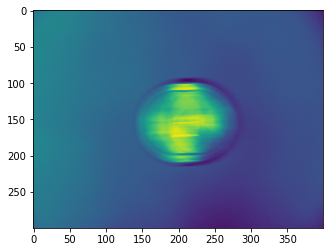

In [25]:
plt.imshow(image)

In [26]:
def color_quantization(image, n):
    data = np.float32(image).reshape((-1, 3))
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
    
    ret, label, center = cv2.kmeans(data, n, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    center = np.uint8(center)
    result = center[label.flatten()]
    result = result.reshape(image.shape)
    
    return result

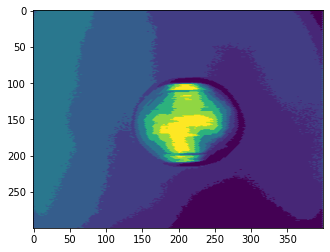

In [27]:
color_8 = color_quantization(image, 8)
plt.imshow(color_8)

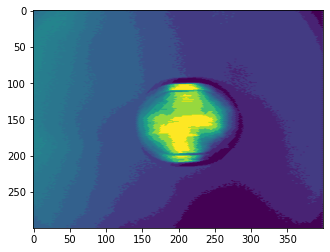

In [28]:
color_16 = color_quantization(image, 16)
plt.imshow(color_16)

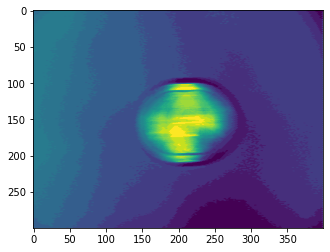

In [29]:
color_32 = color_quantization(image, 32)
plt.imshow(color_32)

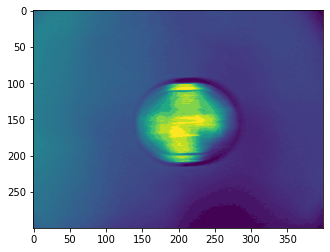

In [30]:
color_64 = color_quantization(image, 64)
plt.imshow(color_64)

**3. Обробка текстових даних**

In [28]:
from sklearn.feature_extraction.text  import CountVectorizer
from sklearn.feature_extraction.text  import TfidfTransformer
from sklearn.naive_bayes              import MultinomialNB
from wordcloud                        import WordCloud,STOPWORDS

import string
import re

import nltk

from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\1\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\1\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\wordnet.zip.


True

In [22]:
amazon_text = pd.read_csv('Amazon_text.csv')
amazon_text.head()

,Review,Label
0,Stuning even for the non-gamer: This sound tr...,__label__2
1,The best soundtrack ever to anything.: I'm re...,__label__2
2,Amazing!: This soundtrack is my favorite musi...,__label__2
3,Excellent Soundtrack: I truly like this sound...,__label__2
4,"Remember, Pull Your Jaw Off The Floor After H...",__label__2


In [23]:
amazon_text['Label']=amazon_text['Label'].map({'__label__2 ':1,'__label__1 ':0}) 
amazon_text[:50]

,Review,Label
0,Stuning even for the non-gamer: This sound tr...,1
1,The best soundtrack ever to anything.: I'm re...,1
2,Amazing!: This soundtrack is my favorite musi...,1
3,Excellent Soundtrack: I truly like this sound...,1
4,"Remember, Pull Your Jaw Off The Floor After H...",1
5,an absolute masterpiece: I am quite sure any ...,1
6,"Buyer beware: This is a self-published book, ...",0
7,Glorious story: I loved Whisper of the wicked...,1
8,A FIVE STAR BOOK: I just finished reading Whi...,1
9,Whispers of the Wicked Saints: This was a eas...,1


In [24]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [25]:
amazon_text['clean_review'] = amazon_text['Review'].apply(lambda x: "".join([i for i in x if i not in string.punctuation]))
amazon_text.head()

,Review,Label,clean_review
0,Stuning even for the non-gamer: This sound tr...,1,Stuning even for the nongamer This sound trac...
1,The best soundtrack ever to anything.: I'm re...,1,The best soundtrack ever to anything Im readi...
2,Amazing!: This soundtrack is my favorite musi...,1,Amazing This soundtrack is my favorite music ...
3,Excellent Soundtrack: I truly like this sound...,1,Excellent Soundtrack I truly like this soundt...
4,"Remember, Pull Your Jaw Off The Floor After H...",1,Remember Pull Your Jaw Off The Floor After He...


In [26]:
amazon_text['review_lower']= amazon_text['clean_review'].apply(lambda x: x.lower())
amazon_text

,Review,Label,clean_review,review_lower
0,Stuning even for the non-gamer: This sound tr...,1,Stuning even for the nongamer This sound trac...,stuning even for the nongamer this sound trac...
1,The best soundtrack ever to anything.: I'm re...,1,The best soundtrack ever to anything Im readi...,the best soundtrack ever to anything im readi...
2,Amazing!: This soundtrack is my favorite musi...,1,Amazing This soundtrack is my favorite music ...,amazing this soundtrack is my favorite music ...
3,Excellent Soundtrack: I truly like this sound...,1,Excellent Soundtrack I truly like this soundt...,excellent soundtrack i truly like this soundt...
4,"Remember, Pull Your Jaw Off The Floor After H...",1,Remember Pull Your Jaw Off The Floor After He...,remember pull your jaw off the floor after he...
...,...,...,...,...
194,A Book That Is Worth a Second Look: This book...,1,A Book That Is Worth a Second Look This book ...,a book that is worth a second look this book ...
195,Best game ever: This games makes even amazing...,1,Best game ever This games makes even amazing ...,best game ever this games makes even amazing ...
196,Guitar in Absentia: With all due respect to a...,0,Guitar in Absentia With all due respect to am...,guitar in absentia with all due respect to am...
197,Stiff and Smells like drying paint: You get w...,0,Stiff and Smells like drying paint You get wh...,stiff and smells like drying paint you get wh...


In [29]:
amazon_text['review_tokenied'] = amazon_text['review_lower'].apply(lambda x: word_tokenize(x))
amazon_text.head()

,Review,Label,clean_review,review_lower,review_tokenied
0,Stuning even for the non-gamer: This sound tr...,1,Stuning even for the nongamer This sound trac...,stuning even for the nongamer this sound trac...,"[stuning, even, for, the, nongamer, this, soun..."
1,The best soundtrack ever to anything.: I'm re...,1,The best soundtrack ever to anything Im readi...,the best soundtrack ever to anything im readi...,"[the, best, soundtrack, ever, to, anything, im..."
2,Amazing!: This soundtrack is my favorite musi...,1,Amazing This soundtrack is my favorite music ...,amazing this soundtrack is my favorite music ...,"[amazing, this, soundtrack, is, my, favorite, ..."
3,Excellent Soundtrack: I truly like this sound...,1,Excellent Soundtrack I truly like this soundt...,excellent soundtrack i truly like this soundt...,"[excellent, soundtrack, i, truly, like, this, ..."
4,"Remember, Pull Your Jaw Off The Floor After H...",1,Remember Pull Your Jaw Off The Floor After He...,remember pull your jaw off the floor after he...,"[remember, pull, your, jaw, off, the, floor, a..."


In [30]:
STOPWORDS

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'all',
 'also',
 'am',
 'an',
 'and',
 'any',
 'are',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 "can't",
 'cannot',
 'com',
 'could',
 "couldn't",
 'did',
 "didn't",
 'do',
 'does',
 "doesn't",
 'doing',
 "don't",
 'down',
 'during',
 'each',
 'else',
 'ever',
 'few',
 'for',
 'from',
 'further',
 'get',
 'had',
 "hadn't",
 'has',
 "hasn't",
 'have',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'hence',
 'her',
 'here',
 "here's",
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 "how's",
 'however',
 'http',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 "isn't",
 'it',
 "it's",
 'its',
 'itself',
 'just',
 'k',
 "let's",
 'like',
 'me',
 'more',
 'most',
 "mustn't",
 'my',
 'myself',
 'no',
 'nor',
 'not',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 'otherwise',
 'ought',
 'our',
 

In [31]:
amazon_text['no_stopwords']= amazon_text['review_tokenied'].apply(lambda x: [i for i in x if i not in STOPWORDS])
amazon_text.head()

,Review,Label,clean_review,review_lower,review_tokenied,no_stopwords
0,Stuning even for the non-gamer: This sound tr...,1,Stuning even for the nongamer This sound trac...,stuning even for the nongamer this sound trac...,"[stuning, even, for, the, nongamer, this, soun...","[stuning, even, nongamer, sound, track, beauti..."
1,The best soundtrack ever to anything.: I'm re...,1,The best soundtrack ever to anything Im readi...,the best soundtrack ever to anything im readi...,"[the, best, soundtrack, ever, to, anything, im...","[best, soundtrack, anything, im, reading, lot,..."
2,Amazing!: This soundtrack is my favorite musi...,1,Amazing This soundtrack is my favorite music ...,amazing this soundtrack is my favorite music ...,"[amazing, this, soundtrack, is, my, favorite, ...","[amazing, soundtrack, favorite, music, time, h..."
3,Excellent Soundtrack: I truly like this sound...,1,Excellent Soundtrack I truly like this soundt...,excellent soundtrack i truly like this soundt...,"[excellent, soundtrack, i, truly, like, this, ...","[excellent, soundtrack, truly, soundtrack, enj..."
4,"Remember, Pull Your Jaw Off The Floor After H...",1,Remember Pull Your Jaw Off The Floor After He...,remember pull your jaw off the floor after he...,"[remember, pull, your, jaw, off, the, floor, a...","[remember, pull, jaw, floor, hearing, youve, p..."


In [32]:
from nltk.stem.porter import PorterStemmer

In [33]:
stemmer = PorterStemmer()

In [34]:
amazon_text['stemmer']= amazon_text['no_stopwords'].apply(lambda x: [stemmer.stem(i) for i in x])
amazon_text.head()

,Review,Label,clean_review,review_lower,review_tokenied,no_stopwords,stemmer
0,Stuning even for the non-gamer: This sound tr...,1,Stuning even for the nongamer This sound trac...,stuning even for the nongamer this sound trac...,"[stuning, even, for, the, nongamer, this, soun...","[stuning, even, nongamer, sound, track, beauti...","[stune, even, nongam, sound, track, beauti, pa..."
1,The best soundtrack ever to anything.: I'm re...,1,The best soundtrack ever to anything Im readi...,the best soundtrack ever to anything im readi...,"[the, best, soundtrack, ever, to, anything, im...","[best, soundtrack, anything, im, reading, lot,...","[best, soundtrack, anyth, im, read, lot, revie..."
2,Amazing!: This soundtrack is my favorite musi...,1,Amazing This soundtrack is my favorite music ...,amazing this soundtrack is my favorite music ...,"[amazing, this, soundtrack, is, my, favorite, ...","[amazing, soundtrack, favorite, music, time, h...","[amaz, soundtrack, favorit, music, time, hand,..."
3,Excellent Soundtrack: I truly like this sound...,1,Excellent Soundtrack I truly like this soundt...,excellent soundtrack i truly like this soundt...,"[excellent, soundtrack, i, truly, like, this, ...","[excellent, soundtrack, truly, soundtrack, enj...","[excel, soundtrack, truli, soundtrack, enjoy, ..."
4,"Remember, Pull Your Jaw Off The Floor After H...",1,Remember Pull Your Jaw Off The Floor After He...,remember pull your jaw off the floor after he...,"[remember, pull, your, jaw, off, the, floor, a...","[remember, pull, jaw, floor, hearing, youve, p...","[rememb, pull, jaw, floor, hear, youv, play, g..."


In [43]:
amazon_text['review_result'] = amazon_text['stemmer'].apply(lambda x: " ".join([i for i in x]))

In [48]:
X = amazon_text['review_result']
y = amazon_text['Label']

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [50]:
X_train

133    good howto manual expect book full glossi shar...
48     terribl buy bought wife birthdayand toreturn d...
4      rememb pull jaw floor hear youv play game know...
63     unknown africa dont expect music africa profes...
22     anoth abysm digit copi rather scratch insect d...
                             ...                        
32     titl hollywood debacl plot ridicul wonder even...
120    worth wait jmm never releas bad album mani say...
104    addon portabl cd drive disappoint perform disa...
187    mask maker like film everi horror like type mo...
102    ye got book wasnt expect much man wrong love b...
Name: review_result, Length: 139, dtype: object

In [55]:
count_vectorizer = CountVectorizer(max_features=1000, stop_words='english')
train_count_vectorizer = count_vectorizer.fit_transform(X_train)
test_count_vectorizer = count_vectorizer.transform(X_test)
    
clf = LogisticRegression(random_state=0).fit(train_count_vectorizer, y_train)
y_pred = clf.predict(test_count_vectorizer)

In [56]:
print(classification_report(y_pred, y_test, digits=4))

              precision    recall  f1-score   support

           0     0.6667    0.6667    0.6667        27
           1     0.7273    0.7273    0.7273        33

    accuracy                         0.7000        60
   macro avg     0.6970    0.6970    0.6970        60
weighted avg     0.7000    0.7000    0.7000        60



In [57]:
count_vectorizer = CountVectorizer(stop_words='english', ngram_range=(1, 2))
train_count_vectorizer = count_vectorizer.fit_transform(X_train)
test_count_vectorizer = count_vectorizer.transform(X_test)

clf = LogisticRegression(random_state=0).fit(train_count_vectorizer, y_train)
y_pred = clf.predict(test_count_vectorizer)

In [58]:
print(classification_report(y_pred, y_test, digits=4))

              precision    recall  f1-score   support

           0     0.5926    0.6957    0.6400        23
           1     0.7879    0.7027    0.7429        37

    accuracy                         0.7000        60
   macro avg     0.6902    0.6992    0.6914        60
weighted avg     0.7130    0.7000    0.7034        60



In [61]:
tfidf_vectorizer = TfidfVectorizer()

tfidf_train = tfidf_vectorizer.fit_transform(X_train)
tfidf_test =  tfidf_vectorizer.transform(X_test)

clf = LogisticRegression().fit(tfidf_train, y_train)

y_pred = clf.predict(tfidf_test)

In [62]:
print(classification_report(y_pred, y_test, digits=4))

              precision    recall  f1-score   support

           0     0.3704    0.7692    0.5000        13
           1     0.9091    0.6383    0.7500        47

    accuracy                         0.6667        60
   macro avg     0.6397    0.7038    0.6250        60
weighted avg     0.7924    0.6667    0.6958        60



In [64]:
def visualize(label):
    text = ''
    for msg in amazon_text[amazon_text['Label'] == label]['review_result']:
        #msg = msg.lower()
        text += msg + ' '
    wordcloud = WordCloud(width=600, height=400, background_color="white").generate(text)
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.show()

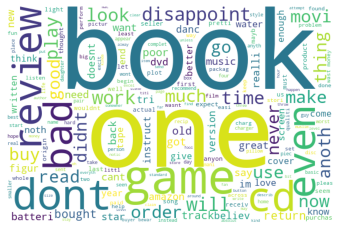

In [65]:
visualize(0)

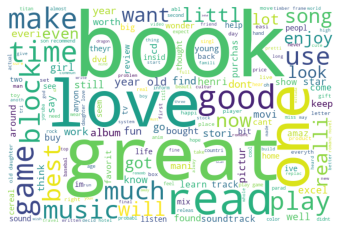

In [66]:
visualize(1)

In [67]:
from sklearn.decomposition import LatentDirichletAllocation

In [68]:
def plot_top_words(model, feature_names, n_top_words, title):
    fig, axes = plt.subplots(1, 4, figsize=(30, 15), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f'Topic {topic_idx +1}',
                     fontdict={'fontsize': 30})
        ax.invert_yaxis()
        ax.tick_params(axis='both', which='major', labelsize=20)
        for i in 'top right left'.split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=40)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()

In [69]:
n_components = 4
n_top_words = 10

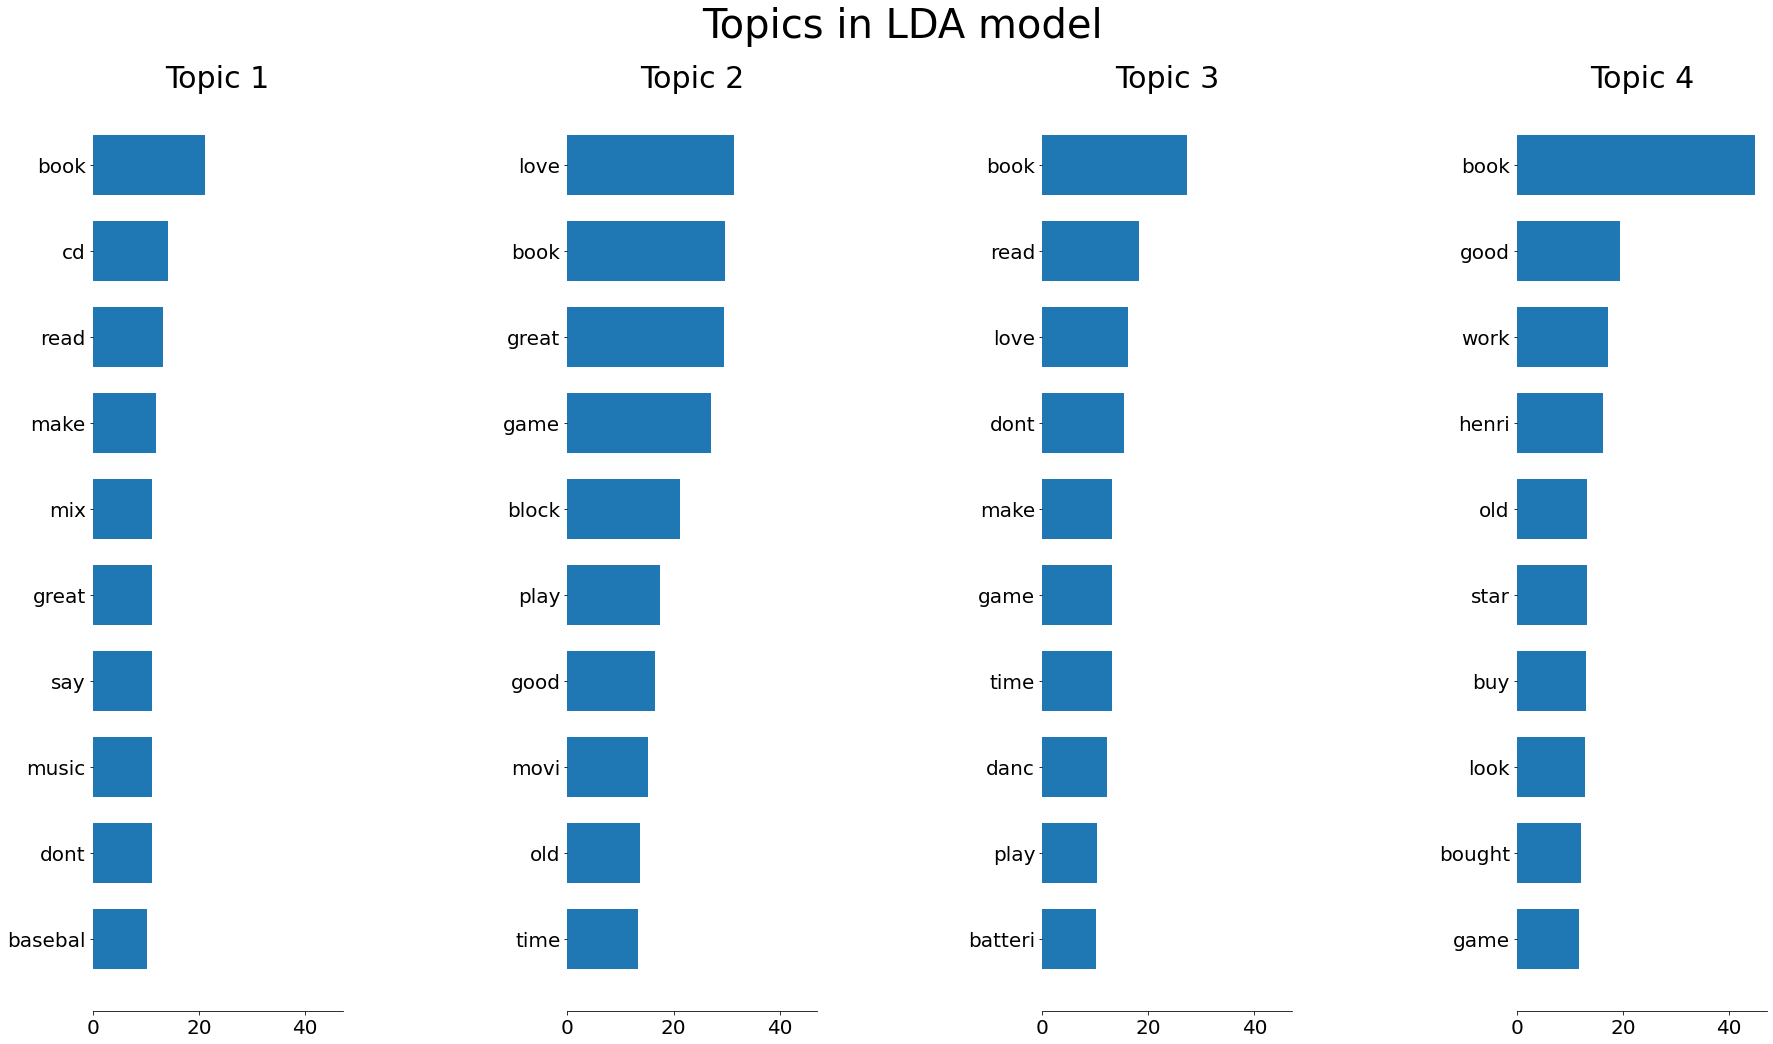

In [70]:
vectorizer = CountVectorizer(stop_words='english')

data_vectorized = vectorizer.fit_transform(X)

lda = LatentDirichletAllocation(n_components=n_components, random_state=0)

lda.fit(data_vectorized)

feature_names = vectorizer.get_feature_names()
plot_top_words(lda, feature_names, n_top_words, 'Topics in LDA model')